In [1]:
# Core data handling
import numpy as np
import pandas as pd
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
# Modeling
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('Historical Product Demand.csv')
df.shape

(1048575, 5)

## found the bracket issue in Order_Demand again
need to flag brackets BEFORE converting to numeric this time, last time i converted first and lost the info lol

In [3]:
is_negative = df['Order_Demand'].astype(str).str.contains(r'\(', regex=True)
print(is_negative.sum())

10469


In [4]:
cleaned = (
    df['Order_Demand']
    .astype(str)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

In [5]:
# check for any values that still dont convert, this time its a real check since brackets are already stripped
cleaned_test = pd.to_numeric(cleaned, errors='coerce')
bad_mask = cleaned_test.isna() & df['Order_Demand'].notna()
print(bad_mask.sum())
df.loc[bad_mask, 'Order_Demand'].unique()[:30]

0


array([], dtype=object)

In [6]:
cleaned = pd.to_numeric(cleaned, errors='coerce')
cleaned[is_negative] = cleaned[is_negative] * -1

df['Order_Demand'] = cleaned
df['Order_Demand'].min(), df['Order_Demand'].max(), df['Order_Demand'].isna().sum()

(np.int64(-999000), np.int64(4000000), np.int64(0))

min should be negative now, if its still 0 something is still broken

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Product_Code      1048575 non-null  object        
 1   Warehouse         1048575 non-null  object        
 2   Product_Category  1048575 non-null  object        
 3   Date              1037336 non-null  datetime64[ns]
 4   Order_Demand      1048575 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 40.0+ MB


In [8]:
df.describe()

,Date,Order_Demand
count,1037336,1.048575e+06
mean,2014-06-17 05:14:07.756175104,4.867427e+03
min,2011-01-08 00:00:00,-9.990000e+05
25%,2013-04-05 00:00:00,1.800000e+01
50%,2014-06-10 00:00:00,3.000000e+02
75%,2015-08-26 00:00:00,2.000000e+03
max,2017-01-09 00:00:00,4.000000e+06
std,NaN,2.893346e+04


## duplicates
checking full row dupes vs just (product, warehouse, date) dupes ignoring demand column
if the second number is way bigger than first, means same product/warehouse got ordered multiple times same day and i should sum not drop

In [9]:
print('full row:', df.duplicated().sum())
print('subset (no demand col):', df.duplicated(subset=['Product_Code','Warehouse','Date']).sum())

full row: 122423
subset (no demand col): 413940


gonna fix grain properly instead of dropping - groupby sum. this handles both the exact dupes and the real multi order same day case at once

In [10]:
df = (
    df.groupby(['Product_Code','Warehouse','Product_Category','Date'], as_index=False, dropna=False)
    ['Order_Demand'].sum()
)
df.shape

(634635, 5)

## missing dates
from before - all 11239 missing dates are from Whse_A only (~7.3% of that warehouse, ~1% overall)

In [11]:
df['Date'].isna().sum()

np.int64(82)

In [12]:
df[df['Date'].isna()].groupby('Warehouse').size()

Warehouse
Whse_A    82
dtype: int64

dropping these rows since i cant recover the date from anywhere else. doing product-category level forecasting anyway not comparing warehouses so this is fine, just noting Whse_A demand history might be slightly undercounted

In [13]:
df = df.dropna(subset=['Date']).reset_index(drop=True)
df.shape

(634553, 5)

In [14]:
df.isnull().sum()

Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
dtype: int64

phase 1 done - grain fixed, signs fixed, missing dates handled. moving to phase 2 next (product vs category level, daily vs weekly)

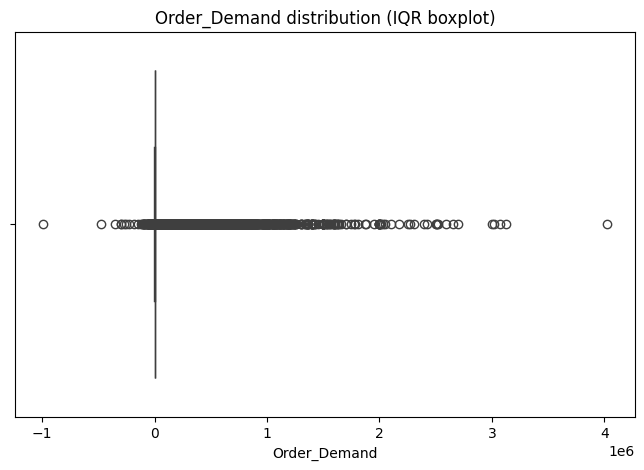

Q1: 16.0, Q3: 2000.0, IQR: 1984.0
Lower bound: -2960.0, Upper bound: 4976.0
Number of outliers: 115546 (18.21% of data)


In [16]:
import numpy as np

# Boxplot - visualizes IQR directly (box = Q1 to Q3, whiskers, dots = outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Order_Demand'])
plt.title('Order_Demand distribution (IQR boxplot)')
plt.show()

# Actual numeric IQR bounds
Q1 = df['Order_Demand'].quantile(0.25)
Q3 = df['Order_Demand'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

outliers = df[(df['Order_Demand'] < lower_bound) | (df['Order_Demand'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]} ({outliers.shape[0]/df.shape[0]*100:.2f}% of data)")

In [19]:
row = df[df['Order_Demand'] == df['Order_Demand'].max()]
print(row)

product_code = row['Product_Code'].values[0]
df[df['Product_Code'] == product_code]['Order_Demand'].describe()


        Product_Code Warehouse Product_Category       Date  Order_Demand
429934  Product_1432    Whse_S     Category_019 2012-06-11       4020000


count    1.932000e+03
mean     5.020963e+04
std      2.276551e+05
min     -7.800000e+04
25%      5.000000e+03
50%      1.000000e+04
75%      3.100000e+04
max      4.020000e+06
Name: Order_Demand, dtype: float64

In [20]:
Q1 = 5000
Q3 = 31000
IQR = Q3 - Q1
upper_bound = Q3 + 1.5*IQR
print(upper_bound)


70000.0


In [22]:
def get_bounds(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({'lower': q1 - 1.5*iqr, 'upper': q3 + 1.5*iqr})

# get iqr bounds per product instead of for the whole column
bounds = df.groupby('Product_Code')['Order_Demand'].apply(get_bounds).unstack()
bounds.head()

,lower,upper
Product_Code,,
Product_0001,-1000.0,2200.0
Product_0002,-37500.0,70500.0
Product_0003,-500.0,1100.0
Product_0004,-250.0,950.0
Product_0005,-550.0,1450.0


In [23]:
# attach each product's own bounds back to its rows
df = df.merge(bounds, on='Product_Code', how='left')

In [24]:
# flag outliers using each row's own product bounds now, not the global one
df['is_outlier'] = (df['Order_Demand'] < df['lower']) | (df['Order_Demand'] > df['upper'])

print(df['is_outlier'].sum(), df['is_outlier'].mean()*100)

58715 9.252970201070674


In [25]:
# check what actually got flagged
df[df['is_outlier']].sort_values('Order_Demand', ascending=False).head(10)

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,lower,upper,is_outlier
429934,Product_1432,Whse_S,Category_019,2012-06-11,4020000,-34000.0,70000.0,True
367753,Product_1341,Whse_C,Category_019,2012-02-06,3125000,-157750.0,316250.0,True
326757,Product_1248,Whse_J,Category_019,2013-11-11,3072000,-317000.0,675000.0,True
326429,Product_1248,Whse_J,Category_019,2012-07-05,3014000,-317000.0,675000.0,True
430002,Product_1432,Whse_S,Category_019,2013-06-14,3000000,-34000.0,70000.0,True
458908,Product_1480,Whse_C,Category_019,2013-10-11,2700000,-52500.0,95500.0,True
430207,Product_1432,Whse_S,Category_019,2016-07-29,2655000,-34000.0,70000.0,True
326529,Product_1248,Whse_J,Category_019,2012-11-26,2592000,-317000.0,675000.0,True
430169,Product_1432,Whse_S,Category_019,2015-10-09,2520000,-34000.0,70000.0,True
430137,Product_1432,Whse_S,Category_019,2015-03-13,2510000,-34000.0,70000.0,True


In [26]:
df[df['is_outlier']].groupby('Product_Code').size().sort_values(ascending=False).head(10)

Product_Code
Product_2167    354
Product_1278    315
Product_1016    314
Product_1886    288
Product_0349    274
Product_0083    262
Product_1470    234
Product_0033    233
Product_1025    229
Product_0979    218
dtype: int64

In [27]:
df.groupby('Product_Code').size().describe()

count    2160.000000
mean      293.774537
std       345.958030
min         1.000000
25%        86.750000
50%       165.000000
75%       354.250000
max      2411.000000
dtype: float64

In [28]:
df = df[~df['is_outlier']].drop(columns=['lower', 'upper', 'is_outlier']).reset_index(drop=True)
df.shape

(575838, 5)

In [29]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0001,Whse_A,Category_005,2012-01-03,1000
1,Product_0001,Whse_A,Category_005,2012-01-04,200
2,Product_0001,Whse_A,Category_005,2012-01-09,2000
3,Product_0001,Whse_A,Category_005,2012-01-30,200
4,Product_0001,Whse_A,Category_005,2012-02-20,1000


In [30]:
df.groupby('Product_Code').size().describe()

count    2160.000000
mean      266.591667
std       314.525829
min         1.000000
25%        77.000000
50%       149.000000
75%       322.000000
max      2099.000000
dtype: float64

In [31]:
product_counts = df.groupby('Product_Code').size()
print((product_counts >= 52).sum(), "products have 52+ rows")
print((product_counts >= 52).mean() * 100, "% of products")


1825 products have 52+ rows
84.49074074074075 % of products


In [33]:
weekly = (
    df.groupby(['Product_Code', pd.Grouper(key='Date', freq='W')])['Order_Demand']
    .sum()
    .reset_index()
)

weekly_counts = weekly.groupby('Product_Code').size()
print((weekly_counts >= 52).sum(), "products have 52+ weeks of data")
print((weekly_counts >= 52).mean() * 100, "%")

1775 products have 52+ weeks of data
82.17592592592592 %
